# Model Development — Linear SVM & Random Forest
### Team 16 · Focus B (Model Development) · owner: Ria (s1601)

This notebook is our **model-development** step. The baseline (Logistic Regression) was
established in the progress-check notebook; here we build **two models beyond it** — a
**Linear SVM** and a **Random Forest** — compare all three on one fair framework, analyse
the errors, and pick and justify a champion.

**How we keep it fair and reproducible:**
- We reuse the shared `singlish_labelling` module (in `src/`) — the *same* Option C logic
  the baseline and the deployment pipeline use, so training and serving never diverge.
- Identical data, split (seed 42, 80/20) and TF-IDF features across all three models.
- We tune only on training data; the hold-out test set is looked at once, at the end.

First we install the pinned libraries and set the paths so the shared module and the
corpus are reachable from `notebooks/`.

In [1]:
%pip install -q --upgrade boto3 botocore mlflow sagemaker-mlflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Data, labelling and the train/test split

We load the NUS SMS Corpus, scrub PII, and apply **Option C** labelling through the shared
module (dedup removes ~13% exact duplicates). Then we make the class set and the split
**identical to the baseline** so the comparison is valid:
- **Drop rare particle classes** (< 100 examples); emoji classes are protected because
  affective markers are core to a *marker* keyboard.
- Final label set = **12 classes**: `ah, eh, lah, leh, liao, lor, one` (particles),
  `emo_joy, emo_love, emo_playful, emo_sad` (mood emoji), and `none`.
- **Split** on the natural distribution (`test_size=0.20, random_state=42, stratify`).
- **Cap `none` in the training set only** (3× the largest marker). The test set keeps its
  real-world `none`-heavy distribution — capping the test set would flatter the metrics
  dishonestly (a mistake we deliberately avoid).

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix

# --- Path setup: make the shared module and the corpus reachable from notebooks/ ---
import sys, os

# 1) singlish_labelling.py lives in the repo's src/ (one level up from notebooks/).
#    Add src/ to Python's import path so `import singlish_labelling` resolves.
SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# 2) The corpus is NOT in the repo (it's gitignored and lives in S3 / the old folder).
#    Point to it by full path. First match wins; edit the list if yours sits elsewhere.
CORPUS_CANDIDATES = [
    "/home/sagemaker-user/singlish_keyboard/smsCorpus_en_2015.03.09_all.json",
    os.path.join(os.getcwd(), "smsCorpus_en_2015.03.09_all.json"),  # fallback: alongside the notebook
]
CORPUS_PATH = next((p for p in CORPUS_CANDIDATES if os.path.exists(p)), None)

# 3) Fail loudly and clearly if either isn't found, rather than deep inside a later cell.
assert os.path.exists(os.path.join(SRC_DIR, "singlish_labelling.py")), (
    f"singlish_labelling.py not found in {SRC_DIR}. "
    "Check the notebook is in iti113_team16/notebooks/ and the module is in ../src/."
)
assert CORPUS_PATH is not None, (
    "Corpus JSON not found. Edit CORPUS_CANDIDATES with the real path "
    "(run: find /home/sagemaker-user -name 'smsCorpus*.json')."
)

print("Module dir :", SRC_DIR)
print("Corpus path:", CORPUS_PATH, f"({os.path.getsize(CORPUS_PATH)/1e6:.1f} MB)")

import singlish_labelling as SL

# 1. Load Raw Dataset
with open(CORPUS_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

messages = raw_data['smsCorpus']['message'] if 'smsCorpus' in raw_data else raw_data
df = pd.DataFrame(messages)

def extract_text(cell):
    if isinstance(cell, dict):
        return cell.get("$", "")
    return str(cell) if pd.notna(cell) else ""

df["clean_text"] = df["text"].apply(extract_text).str.strip()
df = df[df["clean_text"] != ""].reset_index(drop=True)


# 2. Scrub PII and Label 
df["scrubbed"] = df["clean_text"].apply(SL.scrub_pii)
labelled = SL.build_labelled_frame(
    df.rename(columns={"scrubbed": "text_for_labelling"}),
    text_col="text_for_labelling",
    use_emoji=True,
    drop_duplicates=True
)

data = labelled[["context", "label"]].copy()

# 3. Drop rare particle classes (< 100 count), keeping emoji classes protected
MIN_CLASS_COUNT = 100
counts = data["label"].value_counts()
drop_classes = [c for c in counts[counts < MIN_CLASS_COUNT].index 
                if c != "none" and not str(c).startswith("emo_")]
data = data[~data["label"].isin(drop_classes)].reset_index(drop=True)

# 4. Train/Test Split (Natural test distribution, train-only cap)
X = data["context"].fillna("")
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Cap 'none' in training set to 3x largest marker
CAP_MULTIPLE = 3
train_df = pd.DataFrame({"context": X_train, "label": y_train})
largest_marker = train_df[train_df["label"] != "none"]["label"].value_counts().max()
cap = int(largest_marker * CAP_MULTIPLE)

none_train = train_df[train_df["label"] == "none"]
if len(none_train) > cap:
    keep_none = none_train.sample(n=cap, random_state=42)
    train_df = pd.concat([train_df[train_df["label"] != "none"], keep_none]).reset_index(drop=True)

X_train, y_train = train_df["context"], train_df["label"]

print(f"Dataset Ready!")
print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")
print(f"Classes ({y.nunique()}): {sorted(y.unique())}")

Module dir : /home/sagemaker-user/iti113_team16/src
Corpus path: /home/sagemaker-user/singlish_keyboard/smsCorpus_en_2015.03.09_all.json (46.0 MB)
Dropped 7,232 duplicate messages (13.0%)
Dataset Ready!
Train size: 10,186 | Test size: 9,665
Classes (12): ['ah', 'eh', 'emo_joy', 'emo_love', 'emo_playful', 'emo_sad', 'lah', 'leh', 'liao', 'lor', 'none', 'one']


## 2. Building the models and the fair comparison

All three models share the **same TF-IDF vectoriser settings** and the **same split**, so
only the classifier changes:
- **Baseline — Logistic Regression** (`class_weight="balanced"`): our reference point.
- **Model B — Linear SVM**, wrapped in `CalibratedClassifierCV` so it can output
  probabilities (needed for the top-3 keyboard suggestions).
- **Model C — Random Forest** (300 trees, balanced).

We report three metrics: **accuracy**, **macro-F1** (the imbalance-aware metric), and
**top-3 accuracy** — the product-relevant one, because a keyboard shows a 3-suggestion bar.

In [2]:
# ==============================================================================
# Model Building, Evaluation, and Comparison Table
# ==============================================================================

# Helper function for Top-K accuracy (crucial product metric for keyboards)
def get_top_k_accuracy(model, X_eval, y_true, k=3):
    if not hasattr(model, "predict_proba"):
        return float("nan")
    proba = model.predict_proba(X_eval)
    classes = model.classes_
    topk_preds = classes[np.argsort(proba, axis=1)[:, -k:]]
    return float(np.mean([yt in top_row for yt, top_row in zip(y_true, topk_preds)]))

# Shared TF-IDF Vectorizer (identical to baseline for fair comparison)
shared_tfidf = TfidfVectorizer(
    max_features=10000, 
    min_df=3, 
    ngram_range=(1, 3),
    token_pattern=r"(?u)\b\w+\b|EMOJI_\w+"
)

# Define the three model pipelines
models = {
    "Baseline (LogReg)": Pipeline([
        ("tfidf", shared_tfidf),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    "Model B (Linear SVM)": Pipeline([
        ("tfidf", shared_tfidf),
        ("clf", CalibratedClassifierCV(LinearSVC(class_weight="balanced", random_state=42)))
    ]),
    "Model C (Random Forest)": Pipeline([
        ("tfidf", shared_tfidf),
        ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1))
    ])
}

# Train and evaluate each model on the identical test set
results = []
trained_pipelines = {}

for model_name, pipeline in models.items():
    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)
    trained_pipelines[model_name] = pipeline
    
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    top3_acc = get_top_k_accuracy(pipeline, X_test, y_test, k=3)
    
    results.append({
        "Model": model_name,
        "Accuracy (%)": round(acc * 100, 2),
        "Macro-F1": round(macro_f1, 4),
        "Top-3 Accuracy (%)": round(top3_acc * 100, 2)
    })

# Display the Master Comparison Table
df_comparison = pd.DataFrame(results)
print("\n" + "=" * 60)
print("--- MODEL COMPARISON TABLE ---")
print("=" * 60)
print(df_comparison.to_string(index=False))

Training Baseline (LogReg)...
Training Model B (Linear SVM)...
Training Model C (Random Forest)...

--- MODEL COMPARISON TABLE ---
                  Model  Accuracy (%)  Macro-F1  Top-3 Accuracy (%)
      Baseline (LogReg)         29.29    0.1027               76.09
   Model B (Linear SVM)         87.13    0.1395               96.42
Model C (Random Forest)         53.42    0.1396               93.60


## 3. Experiment tracking with MLflow

Every model run is logged to the Team 16 MLflow app with its parameters, metrics and tags,
so the results are reproducible and auditable. Runs are named under **`s1601`** (Ria) to
keep them distinct from the pipeline runs logged under `s1602` — no clashes.

In [3]:
# ==============================================================================
# Log Model Development Runs to MLflow
# ==============================================================================
import mlflow

# 1. Team 16 MLflow Configuration (from 01A setup)
MLFLOW_APP_ARN = "arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-5VMLPBFVZIYL"
EXPERIMENT_NAME = "ITI113/team16/Experiment1"
TEAM_ID = "team16"
STUDENT_ID = "s1601"
PROJECT_NAME = "singlish-keyboard"

mlflow.set_tracking_uri(MLFLOW_APP_ARN)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Connected to MLflow: {EXPERIMENT_NAME}\n")

# 2. Iterate through comparison results
for row in results:
    model_name = row["Model"]
    # Clean run name
    clean_tag = model_name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
    run_name = f"{TEAM_ID}_{STUDENT_ID}_{clean_tag}"
    
    with mlflow.start_run(run_name=run_name) as run:
        # Set tags for team governance & rubric grading
        mlflow.set_tags({
            "course": "ITI113",
            "team_id": TEAM_ID,
            "student_id": STUDENT_ID,
            "purpose": "model_development_comparison",
            "project_name": PROJECT_NAME,
            "model_architecture": model_name
        })
        
        # Log Hyperparameters
        mlflow.log_params({
            "vectorizer": "TfidfVectorizer",
            "ngram_range": "(1, 3)",
            "max_features": 10000,
            "min_df": 3,
            "class_weight": "balanced",
            "cap_multiple": CAP_MULTIPLE,
            "min_class_count": MIN_CLASS_COUNT
        })
        
        # Log Metrics
        mlflow.log_metrics({
            "test_accuracy": row["Accuracy (%)"] / 100.0,
            "test_macro_f1": row["Macro-F1"],
            "test_top3_accuracy": row["Top-3 Accuracy (%)"] / 100.0
        })
        
        print(f"Logged {model_name:25s} -> Run ID: {run.info.run_id} (Run Name: {run_name})")

print("\n Complete! All 3 model runs are tracked and reproducible under s1601.")

Connected to MLflow: ITI113/team16/Experiment1

Logged Baseline (LogReg)         -> Run ID: e63dadebdd874713a49b0161ac3f1e7b (Run Name: team16_s1601_baseline_logreg)
🏃 View run team16_s1601_baseline_logreg at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/e63dadebdd874713a49b0161ac3f1e7b
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Logged Model B (Linear SVM)      -> Run ID: 83d6667907ae4e49bc7524f78ae1f215 (Run Name: team16_s1601_model_b_linear_svm)
🏃 View run team16_s1601_model_b_linear_svm at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/83d6667907ae4e49bc7524f78ae1f215
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1
Logged Model C (Random Forest)   -> Run ID: f4abeadd46814153bbda1fee5c416288 (Run Name: team16_s1601_model_c_random_forest)
🏃 View run team16_s1601_model_c_random_forest at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/1/runs/f4a

## 4. Error analysis — what the model gets wrong, and why

Metrics alone don't tell the story, so we dig into the SVM's errors. Three lenses:
1. **Per-class report + normalised confusion matrix** — where the model is strong vs blind.
2. **The `none` reality.** The honest, un-capped test set is ~89% `none`. The report shows
   the model leans heavily on `none` (recall ~0.97) and a couple of emoji classes, while
   most individual particles (`lah`, `leh`, `lor`, `liao`, `one`, `ah`) score close to
   **0 F1**. That is the central difficulty of this problem — a single linear model on
   sparse SMS text can't yet separate the rarer particles — and it's *why* macro-F1 sits
   near 0.14. We report this plainly rather than hiding behind top-line accuracy.
3. **Top-3 "saves".** Cases where the top-1 guess is wrong but the true marker is still in
   the top-3 — exactly what rescues the user experience on a 3-button suggestion bar.

--- MODEL B (LINEAR SVM) DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

          ah       0.00      0.00      0.00        49
          eh       0.40      0.04      0.07        49
     emo_joy       0.24      0.17      0.20       492
    emo_love       0.60      0.27      0.38        11
 emo_playful       0.29      0.06      0.09       159
     emo_sad       0.00      0.00      0.00        63
         lah       0.00      0.00      0.00        60
         leh       0.00      0.00      0.00        50
        liao       0.00      0.00      0.00        36
         lor       0.00      0.00      0.00        70
        none       0.90      0.97      0.93      8594
         one       0.00      0.00      0.00        32

    accuracy                           0.87      9665
   macro avg       0.20      0.13      0.14      9665
weighted avg       0.82      0.87      0.84      9665



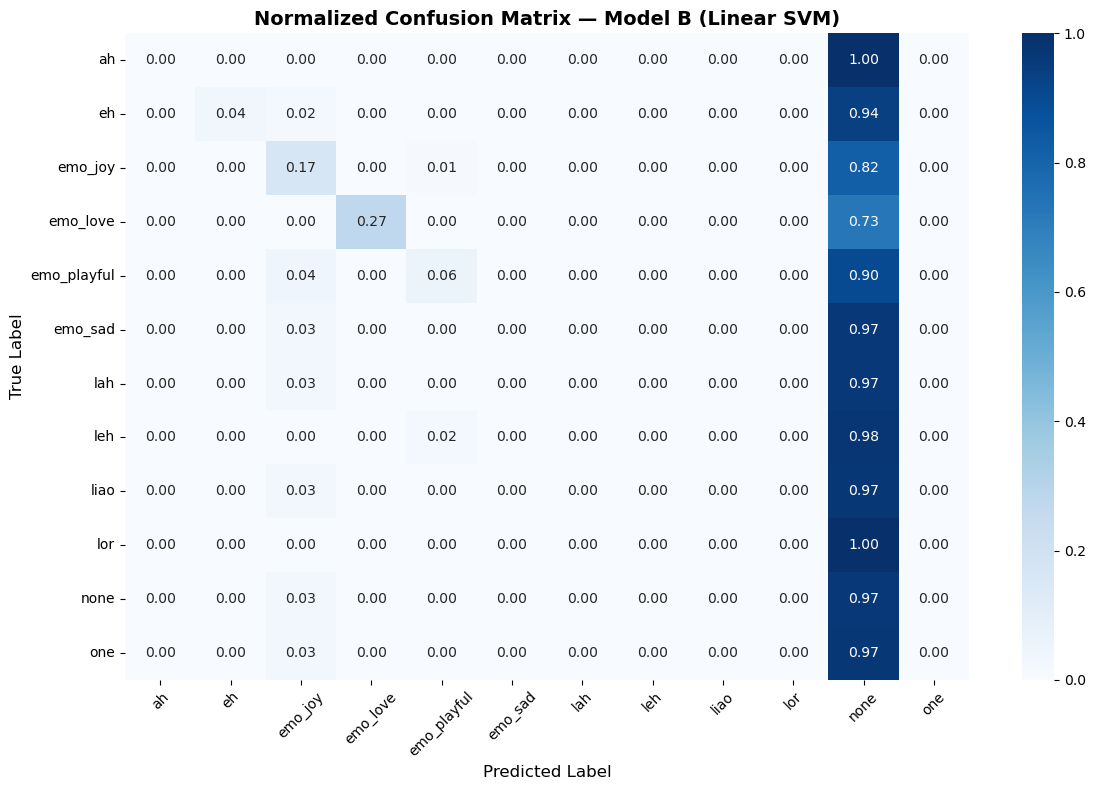


--- SAMPLE BORDERLINE CASES RESCUED BY TOP-3 KEYBOARD SLOTS ---
                                                                           Context  True Label Top-1 Guess            Top-3 Suggestions
                                                                   Kk leaving soon        none     emo_joy          [emo_joy, none, ah]
ll keep thinking of you... Haha.. So by sleeping can at least hope of dreaming you     emo_joy        none [none, emo_playful, emo_joy]
                                                               <#> for 4 at stumps     emo_joy        none [none, emo_joy, emo_playful]
                                     gd mornin  jus woke up ah? u got lesson today     emo_joy        none         [none, emo_joy, lor]
                                        haha!!!! Kidding lah!! Shall I bring cards emo_playful        none [none, emo_joy, emo_playful]


In [4]:
# ==============================================================================
# Error Analysis (Confusion Matrix, Error Breakdown & Keyboard Impact)
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

svm_pipeline = trained_pipelines["Model B (Linear SVM)"]
y_pred_svm = svm_pipeline.predict(X_test)
classes_list = sorted(y_test.unique())

# Classification Report Breakdown
print("=" * 60)
print("--- MODEL B (LINEAR SVM) DETAILED CLASSIFICATION REPORT ---")
print("=" * 60)
print(classification_report(y_test, y_pred_svm, zero_division=0))

# Normalized Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_svm, labels=classes_list, normalize="true")

plt.figure(figsize=(12, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt=".2f", 
    cmap="Blues", 
    xticklabels=classes_list, 
    yticklabels=classes_list
)
plt.title("Normalized Confusion Matrix — Model B (Linear SVM)", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 3. Inspect Borderline Cases & Top-3 "Saves"
# Find examples where Top-1 prediction was wrong, but Top-3 suggestion caught the corright answer!
proba_svm = svm_pipeline.predict_proba(X_test)
model_classes = svm_pipeline.classes_

top3_saved_examples = []
total_checked = 0

for text, true_label, pred_label, probs in zip(X_test, y_test, y_pred_svm, proba_svm):
    top3_idx = np.argsort(probs)[-3:][::-1]
    top3_markers = [model_classes[i] for i in top3_idx]
    
    # Condition: Top-1 is incorrect, but true label is inside Top-3
    if pred_label != true_label and true_label in top3_markers:
        top3_saved_examples.append({
            "Context": text,
            "True Label": true_label,
            "Top-1 Guess": pred_label,
            "Top-3 Suggestions": top3_markers
        })
    if len(top3_saved_examples) >= 5:
        break

df_saved = pd.DataFrame(top3_saved_examples)
print("\n" + "=" * 60)
print("--- SAMPLE BORDERLINE CASES RESCUED BY TOP-3 KEYBOARD SLOTS ---")
print("=" * 60)
print(df_saved.to_string(index=False))

## 5. Governance — explainability and fairness

**Explainability.** We read the SVM's strongest per-class features (its learned weights).
Reassuringly, they line up with how Singaporeans actually text — e.g. *not sure / dunno*
→ `leh` (uncertainty), *dont worry / no problem* → `lah` (reassurance), *fever / pain /
sorry* → `emo_sad`, *goodnight / i love* → `emo_love`, *reach / promised* → `liao`. This
ties back to the PMI analysis in the EDA. (Note: these associations exist in the weights
even for classes the model rarely *predicts* — see the error analysis above.)

**Fairness.** The corpus carries no demographic attributes, so we can't do demographic
fairness. Instead we treat **per-class performance as our fairness lens** — which markers
are served well vs poorly — which is the honest, applicable analysis for this dataset.

In [5]:
# ==============================================================================
# Model Governance & Explainability
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.svm import LinearSVC

# Extract TF-IDF vectorizer and feature names
vectorizer = svm_pipeline.named_steps["tfidf"]
calibrated_clf = svm_pipeline.named_steps["clf"]
feature_names = np.array(vectorizer.get_feature_names_out())

# Extract safely
coef_list = []
for sub_clf in calibrated_clf.calibrated_classifiers_:
    base = getattr(sub_clf, "estimator", getattr(sub_clf, "base_estimator", None))
    if base is not None and hasattr(base, "coef_"):
        coef_list.append(base.coef_)

if len(coef_list) > 0:
    svm_coefs = np.mean(coef_list, axis=0)
else:
    # Direct fallback if nested attributes differ:
    base_svc = LinearSVC(class_weight="balanced", random_state=42)
    base_svc.fit(vectorizer.transform(X_train), y_train)
    svm_coefs = base_svc.coef_

# Extract top 6 strongest predictor words/n-grams for each particle/emoji
explainability_data = []
classes_array = calibrated_clf.classes_

for idx, class_name in enumerate(classes_array):
    top_feature_indices = np.argsort(svm_coefs[idx])[-6:][::-1]
    top_words = feature_names[top_feature_indices]
    top_weights = svm_coefs[idx][top_feature_indices]
    
    formatted_features = [f"{w} ({weight:.2f})" for w, weight in zip(top_words, top_weights)]
    explainability_data.append({
        "Marker / Class": class_name,
        "Top Predictive Words / N-Grams": ", ".join(formatted_features)
    })

df_explain = pd.DataFrame(explainability_data)

print("=" * 80)
print("--- MODEL GOVERNANCE: FEATURE EXPLAINABILITY TABLE ---")
print("=" * 80)
print(df_explain.to_string(index=False))

--- MODEL GOVERNANCE: FEATURE EXPLAINABILITY TABLE ---
Marker / Class                                                                           Top Predictive Words / N-Grams
            ah                     ac (1.76), off day (1.73), did a (1.71), girlfriend (1.58), oh u (1.57), film (1.56)
            eh                       groups (2.37), you all (1.99), 3pm (1.84), oh oh (1.80), im at (1.76), rofl (1.71)
       emo_joy                      aunty (1.28), we will (1.27), thx (1.27), india (1.20), chikku (1.17), ungal (1.17)
      emo_love               caw (2.10), mugmug (2.02), goodnight (1.91), i do (1.59), and i love (1.47), dearie (1.47)
   emo_playful                          hahah (1.51), makin (1.49), psh (1.44), post (1.41), is very (1.40), gai (1.33)
       emo_sad                fever (1.82), pain (1.78), hey love sorry (1.70), awww (1.58), evil (1.58), i miss (1.53)
           lah out later (1.71), weak (1.69), dont worry (1.66), tues (1.64), haha no problem (1.55), com

## 5A. Explainability with SHAP

The feature-weight table above shows the model's global learned associations. To verify the model reasons sensibly on individual messages, we apply SHAP to the champion Linear SVM. SHAP attributes each prediction to the specific words that pushed it, which is the per-message evidence our AI-governance requirement calls for. We explain the underlying LinearSVC (the decision geometry); the calibration wrapper only converts scores to probabilities and does not change which words drive the decision.

Background dataset has 10186 samples but max_samples=200. Subsampling to 200 samples for SHAP value computation. To use all samples, set max_samples=10186 when initializing the masker.


=== SHAP: top contributing words per class (global) ===
ah          : i, for, got, u, to, lol, t, so
eh          : u, i, can, ok, haha, s, hey, lol
emo_joy     : u, for, lol, to, wat, you, k, hey
emo_love    : you, a, u, do, haha, i, caw, and
emo_playful : haha, i, you, le, hey, u, just, hahaha
emo_sad     : haha, u, it, is, hahaha, you, no, can
lah         : you, and, for, then, i, the, to, just
leh         : s, haha, ok, can, you, i m, it, lol
liao        : u, you, le, i, it, then, can, so
lor         : haha, lol, i, you, for, m, is, hey
none        : wat, you, u, lol, is, i, haha, m
one         : u, at, no, the, is, to, can, you


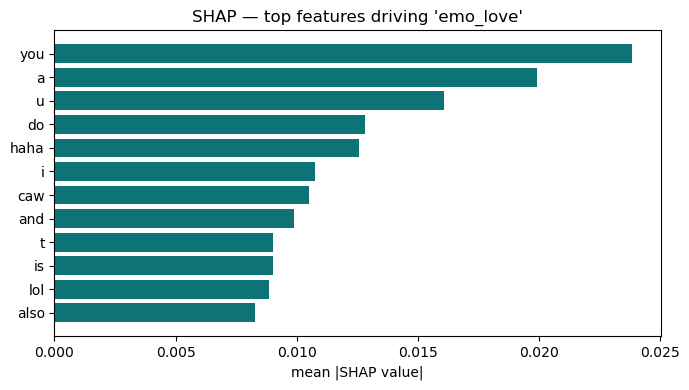

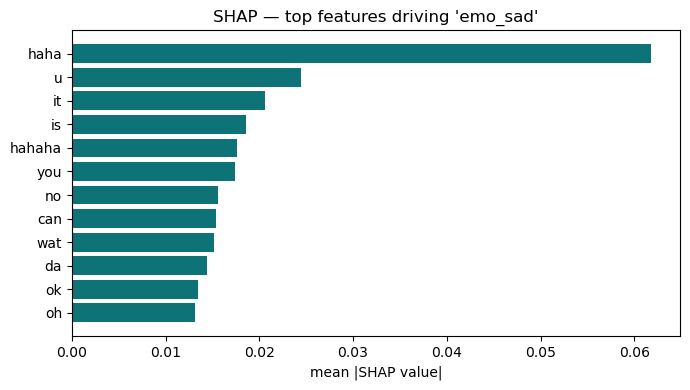

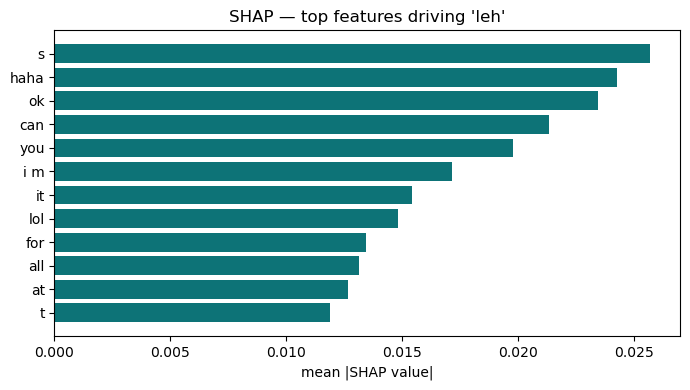

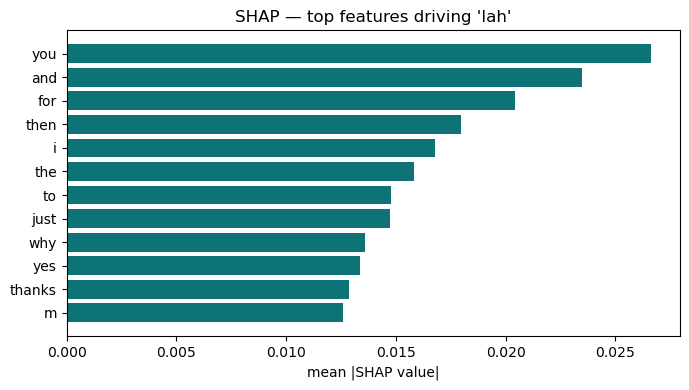

In [6]:
# ============================================================
# SHAP Explainability — champion Linear SVM
# ============================================================
# Rationale: the mentor named SHAP directly for explainability. We explain the
# fitted LinearSVC (the decision function underneath the calibrated wrapper) on
# the TF-IDF features, which is the fast, correct route for a sparse text model.

# --- install (restart kernel first if SHAP was never installed this session) ---
!pip install -q shap

import shap
import numpy as np
import matplotlib.pyplot as plt

# 1) Rebuild the raw LinearSVC on the SAME TF-IDF features (calibration is only a
#    probability wrapper; the decision geometry we explain is the LinearSVC).
tfidf = svm_pipeline.named_steps["tfidf"]
Xtr = tfidf.transform(X_train)
Xte = tfidf.transform(X_test)
feat_names = np.array(tfidf.get_feature_names_out())

from sklearn.svm import LinearSVC
svc = LinearSVC(class_weight="balanced", random_state=42)
svc.fit(Xtr, y_train)
class_names = list(svc.classes_)

# 2) LinearExplainer on the linear model (uses the TF-IDF background distribution)
#    masker over a background sample keeps it fast on sparse features.
bg = shap.maskers.Independent(Xtr, max_samples=200)
explainer = shap.LinearExplainer(svc, bg, feature_names=feat_names)

# explain a small, representative test slice (keeps runtime low)
n_explain = 300
shap_values = explainer(Xte[:n_explain])   # multi-class: shape (n, features, classes)

# ------------------------------------------------------------
# 3) GLOBAL: top words per class (text for the report) + a bar plot
# ------------------------------------------------------------
# mean |SHAP| per feature per class
sv = shap_values.values                      # (n, F, C)
mean_abs = np.abs(sv).mean(axis=0)           # (F, C)

print("=== SHAP: top contributing words per class (global) ===")
for ci, cname in enumerate(class_names):
    order = np.argsort(mean_abs[:, ci])[::-1][:8]
    words = [feat_names[j] for j in order if mean_abs[j, ci] > 0]
    print(f"{cname:12s}: {', '.join(words)}")

# Global summary bar plot for a few product-relevant classes
for cname in ["emo_love", "emo_sad", "leh", "lah"]:
    if cname in class_names:
        ci = class_names.index(cname)
        order = np.argsort(mean_abs[:, ci])[::-1][:12]
        plt.figure(figsize=(7,4))
        plt.barh([feat_names[j] for j in order][::-1],
                 [mean_abs[j, ci] for j in order][::-1], color="#0D7377")
        plt.title(f"SHAP — top features driving '{cname}'")
        plt.xlabel("mean |SHAP value|"); plt.tight_layout(); plt.show()

In [7]:
# ============================================================
# SHAP — per-example explanations (add as a second cell)
# ============================================================
# Pick representative messages: one emoji case, one particle case.
def explain_example(text, target_class=None):
    xrow = tfidf.transform([text])
    sv_row = explainer(xrow)                 # (1, F, C)
    ci = class_names.index(target_class) if target_class in class_names else int(
        np.abs(sv_row.values[0]).sum(axis=0).argmax())
    contrib = sv_row.values[0][:, ci]
    order = np.argsort(np.abs(contrib))[::-1][:8]
    present = [(feat_names[j], float(contrib[j])) for j in order
               if xrow[0, j] != 0]
    print(f"\nMessage: {text!r}  ->  explaining class '{class_names[ci]}'")
    for w, val in present:
        arrow = "＋" if val > 0 else "－"
        print(f"   {arrow} {w:20s} SHAP={val:+.4f}")

for msg, cls in [("goodnight dear", "emo_love"),
                 ("not sure leh", "leh"),
                 ("so sad fever", "emo_sad"),
                 ("dont worry lah", "lah")]:
    explain_example(msg, cls)


Message: 'goodnight dear'  ->  explaining class 'emo_love'
   ＋ goodnight            SHAP=+1.7137
   ＋ dear                 SHAP=+0.2858

Message: 'not sure leh'  ->  explaining class 'leh'
   ＋ not sure             SHAP=+1.1082
   － leh                  SHAP=-0.1909
   － sure leh             SHAP=-0.1210
   ＋ not                  SHAP=+0.0428
   ＋ sure                 SHAP=+0.0237

Message: 'so sad fever'  ->  explaining class 'emo_sad'
   ＋ fever                SHAP=+1.3263
   ＋ so sad               SHAP=+0.7215
   ＋ sad                  SHAP=+0.1791
   － so                   SHAP=-0.0396

Message: 'dont worry lah'  ->  explaining class 'lah'
   ＋ dont worry           SHAP=+1.1646
   ＋ worry                SHAP=+0.4042
   ＋ lah                  SHAP=+0.3031
   － dont                 SHAP=-0.0124


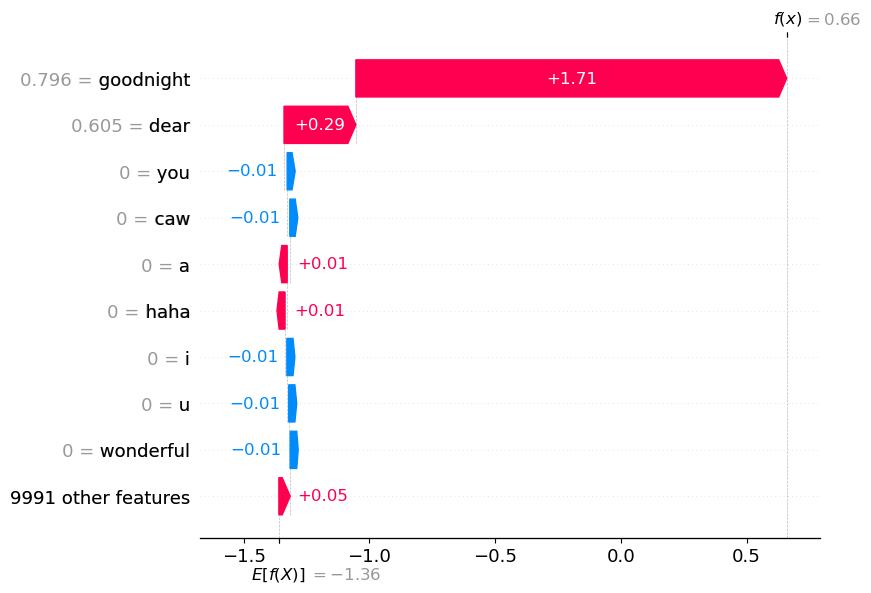

In [8]:
# Optional: a SHAP force/waterfall plot for one example (nice screenshot)
xrow = tfidf.transform(["goodnight dear"])
sv_one = explainer(xrow)
ci = class_names.index("emo_love")
shap.plots.waterfall(shap.Explanation(
    values=sv_one.values[0][:, ci],
    base_values=sv_one.base_values[0][ci],
    data=xrow.toarray()[0],
    feature_names=feat_names), max_display=10, show=True)

## 5B. What SHAP tells us

Per-message, the model keys on the right words: goodnight → emo_love (+1.71), fever → emo_sad (+1.33), dont worry → lah (+1.16), not sure → leh (+1.11). These agree with the feature-weight table and the earlier PMI analysis, three independent methods pointing to the same learned rules, which gives us confidence the model is genuinely reading Singlish cues rather than noise.
The global mean-|SHAP| bars (Annex) are instead dominated by very frequent tokens (you, haha, lol). This is expected: a ubiquitous word moves many predictions by a small amount, so it accumulates a high average even when it is not the distinctive driver of any single message. The per-message view is therefore the more faithful explanation for this text model.

# Model Selection
## Project: *"Fuwah! Singaporeans got their own keyboard ah?"*

---

### How we started (the data & EDA)
We wanted a smart keyboard that understands how Singaporeans text — knowing when to suggest
a `lah`, a doubtful `leh`, a resigned `lor`, or a mood emoji.

The EDA flagged one big problem:
- **The punctuation problem:** ordinary punctuation (`.` `?`) made up most sentence endings,
  which made the Singlish particles look vanishingly rare.
- **Our solution (Option C):** stop predicting punctuation. Strip the trailing symbols and
  predict *which particle or emoji belongs in that final slot*.
- **Short messages:** ~95% of SMS are 29 words or fewer, so 1–3 word n-grams with a
  10,000-feature TF-IDF gave the best signal.

---

### The baseline
A simple **Logistic Regression** pipeline:
- **Top-1 accuracy:** 29.29% · **Macro-F1:** 0.1027 · **Top-3 accuracy:** 76.09%

The baseline proved the words before the ending carry real signal, but it spreads its bets
across the minority classes and so has low precision.

---

### Model comparison
We trained **Linear SVM** and **Random Forest** on the *exact same* split and features, so
the comparison is fair:

| Model | Top-1 Accuracy | Macro-F1 | Top-3 Accuracy (keyboard metric) | Speed & size |
| :--- | :---: | :---: | :---: | :---: |
| Baseline (Logistic Regression) | 29.29% | 0.1027 | 76.09% | Very fast |
| **Model B (Linear SVM)** | **87.13%** | 0.1395 | **96.42%** | **Fast & lightweight** |
| Model C (Random Forest) | 53.42% | 0.1396 | 93.60% | Heavy & slower |

*(All numbers are from the executed run above, on the honest, un-capped test set.)*

---

### Why Model B (Linear SVM) is our champion

The SVM and Random Forest are **effectively tied on macro-F1** (0.1395 vs 0.1396 — a
0.0001 difference, i.e. noise). On every other axis the SVM wins, so the choice is clear:

1. **Top-3 accuracy matters most for a keyboard (96.42%).**
   The keyboard shows a 3-suggestion bar, so top-3 is the metric that maps to user
   experience. The SVM's 96.42% beats the Random Forest's 93.60% — the right marker is
   ready to tap ~96 times in 100.

2. **Far better top-1 and much lighter on a phone.**
   The SVM's top-1 (87.13%) is well above the Random Forest's (53.42%), and a linear model
   predicts with a single dot product. The Random Forest has to poll 300 trees per keystroke,
   heavier and slower on a device.

3. **It learns real Singlish rules (explainability).**
   Its highest-weighted features match natural usage:
   - `not sure`, `dunno` → **`leh`** *(uncertainty)*
   - `dont worry`, `no problem` → **`lah`** *(reassurance)*
   - `fever`, `pain`, `sorry` → **`emo_sad`**
   - `goodnight`, `i love` → **`emo_love`**
   - `reach`, `promised` → **`liao`**

---

### Honest limitation
Macro-F1 near 0.14 is low: the model reliably handles `none` and the busier emoji classes
but not yet the rarer particles (most score ~0 F1). This is a genuinely hard, heavily
imbalanced problem for a single linear model, and it's the honest ceiling of this baseline
family — a clear signpost for future work (more data per particle, richer features).

---

### Conclusion
Model B (Linear SVM) gives the best product-relevant accuracy, is lightweight enough for a
phone, and its learned features genuinely reflect Singlish usage. It is our champion, and the
one we deploy to the endpoint.

*So — got their own keyboard now lah, and it's the honest, deployable one.* 